1. Instalasi Library

In [ ]:
!pip install networkx matplotlib

2. Struktur Data Graf dan Algoritma

In [ ]:
import heapq #membuat priority queue
import networkx as nx #library untuk membuat dan memanipulasi graf
import matplotlib.pyplot as plt #menampilkan visualisasi graf

def dijkstra_with_paths(graph, start):
  distances = {node: float('inf') for node in graph} #inisialisasi jarak, float('inf') berarti tak hingga
  distances[start] = 0 #jarak awal node = 0
  previous = {node: None for node in graph} #menyimpan node sebelumnya, digunakan untuk melacak jalur
  queue = [ (0, start)]

  while queue: #kondisi selama queue tidak kosong
    current_distance, current_node = heapq.heappop(queue) #mengambil jarak terkecil

    for neighbor, weight in graph[current_node].items(): #mengecek semua tetangga
      distance = current_distance + weight #menghitung jarak baru
      if distance < distances[neighbor]: #jika jaraknya lebih pendek
        distances[neighbor] = distance #update jarak
        previous[neighbor] = current_node #menyimpan jalur
        heapq.heappush(queue, (distance, neighbor)) #menyimpan ke queue

  return distances, previous #mengembalikan hasil

3. Fungsi Untuk Merekontruksi Jalur

In [ ]:
def get_path(previous, target): #fungsi untuk membangun kembali jalur terpendek setelah algoritma selesai dijalankan
  path = []
  while target is not None: #kondisi selama belum mencapai awal,
    path.insert(0, target) #menambahkan node ke depan list
    target = previous[target] #mundur ke node sebelumnya
  return path #mengembalikan jalur

4. Visualisasi dengan networkx dan matplotlib

In [ ]:
def visualize_graph(graph, path=None):
  G = nx.DiGraph() #membuat graf berarah

  for node in graph: #mengunjungi setiap node
    for neighbor, weight in graph[node].items(): #mengambil tetangga dan bobot
      G.add_edge(node, neighbor, weight=weight) #menambahkan sisi(edge)
  pos = nx.spring_layout(G) #menentukan posisi node
  edge_labels = nx.get_edge_attributes(G, 'weight') #mengambil bobot node

  plt.figure(figsize=(8, 6)) #membuat canvas
  #menggambar graf
  nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000, font_weight='bold', arrows=True)
  nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

  #Garis tebal untuk jalur terpendek
  if path and len(path) > 1:
    path_edges = list(zip(path, path[1:]))
    nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=3)

  plt.title("Visualisasi graf dan jalur terpendek")
  plt.axis('off')
  plt.show()

5. Penggunaan lengkap

Jarak dari A ke Z: 14
Jalur: A->B->D->E->Z


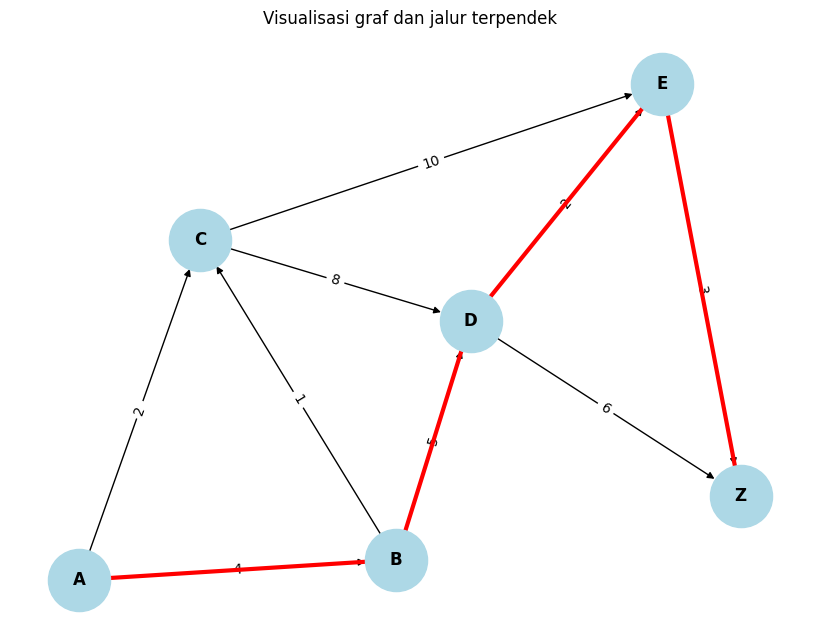

In [ ]:
#Definisi graf
graph = {
    'A': {'B': 4, 'C': 2},
    'B': {'C': 1, 'D': 5},
    'C': {'D': 8, 'E': 10},
    'D': {'E': 2, 'Z': 6},
    'E': {'Z': 3},
    'Z': {}
}

#Jalankan Dijkstra
start_node = 'A' #titik awal
end_node = 'Z' #mencari jalur terpendek menuju Z

#memanggil fungsi
distances, previous = dijkstra_with_paths(graph, start_node)

#Rekonstruksi jalur
shortest_path = get_path(previous, end_node)
print(f'Jarak dari {start_node} ke {end_node}: {distances[end_node] }')
print(f'Jalur: {'->'. join(shortest_path) }')

#Visualisasi
visualize_graph(graph, path=shortest_path)

Tugas

Jarak dari A ke Z: 6
Jalur: A->C->F->Z


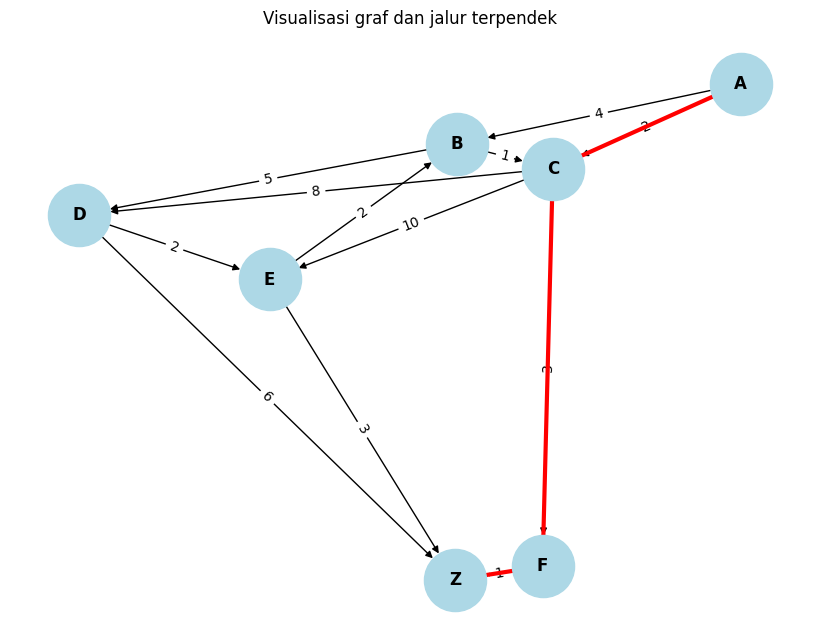

In [11]:
import heapq
import networkx as nx
import matplotlib.pyplot as plt

def dijkstra_with_paths(graph, start):
  distances = {node: float('inf') for node in graph}
  distances[start] = 0
  previous = {node: None for node in graph}
  queue = [ (0, start)]

  while queue:
    current_distance, current_node = heapq.heappop(queue)

    for neighbor, weight in graph[current_node].items():
      distance = current_distance + weight
      if distance < distances[neighbor]:
        distances[neighbor] = distance
        previous[neighbor] = current_node
        heapq.heappush(queue, (distance, neighbor))

  return distances, previous

def get_path(previous, target):
  path = []
  while target is not None:
    path.insert(0, target)
    target = previous[target]
  return path

def visualize_graph(graph, path=None):
  G = nx.DiGraph()

  for node in graph:
    for neighbor, weight in graph[node].items():
      G.add_edge(node, neighbor, weight=weight)
  pos = nx.kamada_kawai_layout(G) #ganti layout
  edge_labels = nx.get_edge_attributes(G, 'weight')

  plt.figure(figsize=(8, 6))
  nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000, font_weight='bold', arrows=True)
  nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

  if path and len(path) > 1:
    path_edges = list(zip(path, path[1:]))
    nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=3)

  plt.title("Visualisasi graf dan jalur terpendek")
  plt.axis('off')
  plt.show()

#Definisi graf
graph = {
    'A': {'B': 4, 'C': 2},
    'B': {'C': 1, 'D': 5},
    'C': {'D': 8, 'E': 10, 'F': 3},
    'D': {'E': 2, 'Z': 6},
    'E': {'Z': 3, 'B': 2}, #modifikasi graf
    'F': {'Z': 1}, #simpul baru tambahan
    'Z': {}
}

#Jalankan Dijkstra
start_node = 'A'
end_node = 'Z'

#memanggil fungsi
distances, previous = dijkstra_with_paths(graph, start_node)

#Rekonstruksi jalur
shortest_path = get_path(previous, end_node)
print(f'Jarak dari {start_node} ke {end_node}: {distances[end_node] }')
print(f'Jalur: {'->'. join(shortest_path) }')

#Visualisasi
visualize_graph(graph, path=shortest_path)